
# 07 — Feature Engineering and Dataset Split

**Product Pulse**

This notebook prepares model-ready train, validation, and test datasets.

### Retailrocket
- chronological split: **60% train / 20% validation / 20% test**
- feature lookback: **21 days**
- recent behavior: **7 days**
- target: transaction in the next **7 days**
- cutoff spacing: **7 days**

### Online Retail II
- chronological split: **70% train / 15% validation / 15% test**
- feature lookback: **180 days**
- recent behavior: **30 days**
- target: purchase in the next **60 days**
- cutoff spacing: **30 days**

Criteo is handled separately in Notebook 09 because it is a randomized experimental dataset rather than a behavioral timeline.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.home() / "Desktop" / "resume_projects" / "ProductPulse"
PROCESSED_02 = PROJECT_ROOT / "data" / "processed" / "02_cleaned"
PROCESSED_07 = PROJECT_ROOT / "data" / "processed" / "07_modeling"

RR_OUT = PROCESSED_07 / "retailrocket"
OR_OUT = PROCESSED_07 / "online_retail"

RR_OUT.mkdir(parents=True, exist_ok=True)
OR_OUT.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Input :", PROCESSED_02)
print("Output:", PROCESSED_07)


Input : /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/02_cleaned
Output: /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling


## 1. Shared helper functions

In [2]:

def safe_divide(a, b):
    return np.where(b != 0, a / b, np.nan)


def make_time_split_boundaries(start_time, end_time_exclusive,
                               train_fraction, validation_fraction):
    start_time = pd.Timestamp(start_time)
    end_time_exclusive = pd.Timestamp(end_time_exclusive)
    total = end_time_exclusive - start_time

    train_end = start_time + total * train_fraction
    validation_end = start_time + total * (
        train_fraction + validation_fraction
    )

    return {
        "train": (start_time, train_end),
        "validation": (train_end, validation_end),
        "test": (validation_end, end_time_exclusive),
    }


def generate_cutoffs(split_start, split_end, data_start,
                     lookback_days, horizon_days, step_days):
    first_possible = max(
        pd.Timestamp(split_start),
        pd.Timestamp(data_start) + pd.Timedelta(days=lookback_days),
    )
    latest_possible = (
        pd.Timestamp(split_end) - pd.Timedelta(days=horizon_days)
    )

    if first_possible > latest_possible:
        return []

    return list(pd.date_range(
        start=first_possible,
        end=latest_possible,
        freq=f"{step_days}D",
    ))


def split_boundary_table(dataset_name, boundaries):
    rows = []
    for split_name, (start, end) in boundaries.items():
        rows.append({
            "dataset": dataset_name,
            "split": split_name,
            "start": start,
            "end_exclusive": end,
            "duration_days": (
                pd.Timestamp(end) - pd.Timestamp(start)
            ).total_seconds() / 86400,
        })
    return pd.DataFrame(rows)



# 2. Retailrocket

For each prediction cutoff:

```text
previous 21 days               next 7 days
<--------------------|------------------------->
      features       cutoff       target
```


In [3]:

EVENTS_PATH = PROCESSED_02 / "retailrocket_events_clean.parquet"

if not EVENTS_PATH.exists():
    raise FileNotFoundError(
        f"{EVENTS_PATH} not found. Run Notebook 02 first."
    )

events = pd.read_parquet(EVENTS_PATH)

if not pd.api.types.is_datetime64_any_dtype(events["event_time"]):
    events["event_time"] = pd.to_datetime(
        events["event_time"], utc=True
    )

events = events.sort_values("event_time").reset_index(drop=True)

rr_data_start = events["event_time"].min().floor("D")
rr_data_end = events["event_time"].max().ceil("D")

print("Retailrocket range:", rr_data_start, "→", rr_data_end)
print("Rows:", f"{len(events):,}")


Retailrocket range: 2015-05-03 00:00:00+00:00 → 2015-09-19 00:00:00+00:00
Rows: 2,755,641


In [4]:

rr_boundaries = make_time_split_boundaries(
    rr_data_start,
    rr_data_end,
    train_fraction=0.60,
    validation_fraction=0.20,
)

rr_boundary_df = split_boundary_table(
    "Retailrocket",
    rr_boundaries,
)

display(rr_boundary_df)


,dataset,split,start,end_exclusive,duration_days
0,Retailrocket,train,2015-05-03 00:00:00+00:00,2015-07-25 09:36:00+00:00,83.4
1,Retailrocket,validation,2015-07-25 09:36:00+00:00,2015-08-22 04:48:00+00:00,27.8
2,Retailrocket,test,2015-08-22 04:48:00+00:00,2015-09-19 00:00:00+00:00,27.8


In [5]:

RR_LOOKBACK_DAYS = 21
RR_RECENT_DAYS = 7
RR_HORIZON_DAYS = 7
RR_STEP_DAYS = 7


def build_retailrocket_example(events, cutoff, split_name):
    cutoff = pd.Timestamp(cutoff)

    history_start = cutoff - pd.Timedelta(days=RR_LOOKBACK_DAYS)
    recent_start = cutoff - pd.Timedelta(days=RR_RECENT_DAYS)
    label_end = cutoff + pd.Timedelta(days=RR_HORIZON_DAYS)

    history = events.loc[
        (events["event_time"] >= history_start)
        & (events["event_time"] < cutoff)
    ].copy()

    future = events.loc[
        (events["event_time"] >= cutoff)
        & (events["event_time"] < label_end)
    ].copy()

    features = (
        history.groupby("visitorid")
        .agg(
            events_21d=("event", "size"),
            unique_items_21d=("itemid", "nunique"),
            first_event_21d=("event_time", "min"),
            last_event_21d=("event_time", "max"),
        )
        .reset_index()
    )

    event_counts = (
        history.groupby(["visitorid", "event"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .rename(columns={
            "view": "views_21d",
            "addtocart": "carts_21d",
            "transaction": "transactions_21d",
        })
    )

    for col in ["views_21d", "carts_21d", "transactions_21d"]:
        if col not in event_counts.columns:
            event_counts[col] = 0

    features = features.merge(
        event_counts[
            ["visitorid", "views_21d", "carts_21d", "transactions_21d"]
        ],
        on="visitorid",
        how="left",
    )

    recent = history.loc[
        history["event_time"] >= recent_start
    ]

    recent_counts = (
        recent.groupby(["visitorid", "event"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .rename(columns={
            "view": "views_7d",
            "addtocart": "carts_7d",
            "transaction": "transactions_7d",
        })
    )

    for col in ["views_7d", "carts_7d", "transactions_7d"]:
        if col not in recent_counts.columns:
            recent_counts[col] = 0

    features = features.merge(
        recent_counts[
            ["visitorid", "views_7d", "carts_7d", "transactions_7d"]
        ],
        on="visitorid",
        how="left",
    )

    features[["views_7d", "carts_7d", "transactions_7d"]] = (
        features[["views_7d", "carts_7d", "transactions_7d"]].fillna(0)
    )

    features["recency_hours"] = (
        (cutoff - features["last_event_21d"]).dt.total_seconds() / 3600
    )

    features["active_span_days_21d"] = (
        (
            features["last_event_21d"]
            - features["first_event_21d"]
        ).dt.total_seconds() / 86400
    )

    features["cart_per_view_21d"] = safe_divide(
        features["carts_21d"],
        features["views_21d"],
    )

    features["transaction_per_view_21d"] = safe_divide(
        features["transactions_21d"],
        features["views_21d"],
    )

    future_transactions = (
        future.loc[future["event"] == "transaction"]
        .groupby("visitorid")
        .size()
        .rename("future_transactions_7d")
        .reset_index()
    )

    features = features.merge(
        future_transactions,
        on="visitorid",
        how="left",
    )

    features["future_transactions_7d"] = (
        features["future_transactions_7d"].fillna(0).astype("int32")
    )

    features["target_future_transaction"] = (
        features["future_transactions_7d"] > 0
    ).astype("int8")

    features["prediction_cutoff"] = cutoff
    features["label_end"] = label_end
    features["split"] = split_name

    return features


In [6]:

rr_split_frames = {}
rr_cutoff_records = []

for split_name, (split_start, split_end) in rr_boundaries.items():
    cutoffs = generate_cutoffs(
        split_start=split_start,
        split_end=split_end,
        data_start=rr_data_start,
        lookback_days=RR_LOOKBACK_DAYS,
        horizon_days=RR_HORIZON_DAYS,
        step_days=RR_STEP_DAYS,
    )

    print(f"{split_name}: {len(cutoffs)} prediction cutoffs")

    frames = []

    for cutoff in cutoffs:
        snapshot = build_retailrocket_example(
            events,
            cutoff,
            split_name,
        )
        frames.append(snapshot)

        rr_cutoff_records.append({
            "split": split_name,
            "prediction_cutoff": cutoff,
            "rows": len(snapshot),
            "positives": int(
                snapshot["target_future_transaction"].sum()
            ),
            "target_rate": (
                snapshot["target_future_transaction"].mean()
                if len(snapshot)
                else np.nan
            ),
        })

    rr_split_frames[split_name] = (
        pd.concat(frames, ignore_index=True)
        if frames
        else pd.DataFrame()
    )

rr_cutoff_summary = pd.DataFrame(rr_cutoff_records)
display(rr_cutoff_summary)


train: 8 prediction cutoffs
validation: 3 prediction cutoffs
test: 3 prediction cutoffs


,split,prediction_cutoff,rows,positives,target_rate
0,train,2015-05-24 00:00:00+00:00,225151,112,0.000497
1,train,2015-05-31 00:00:00+00:00,231937,106,0.000457
2,train,2015-06-07 00:00:00+00:00,235828,99,0.000420
3,train,2015-06-14 00:00:00+00:00,225179,120,0.000533
4,train,2015-06-21 00:00:00+00:00,221774,113,0.000510
5,train,2015-06-28 00:00:00+00:00,217357,95,0.000437
6,train,2015-07-05 00:00:00+00:00,219762,118,0.000537
7,train,2015-07-12 00:00:00+00:00,230595,108,0.000468
8,validation,2015-07-25 09:36:00+00:00,257881,116,0.000450
9,validation,2015-08-01 09:36:00+00:00,268938,97,0.000361


In [7]:

for split_name, df in rr_split_frames.items():
    if df.empty:
        continue

    split_start, split_end = rr_boundaries[split_name]

    assert (df["prediction_cutoff"] >= split_start).all()
    assert (df["label_end"] <= split_end).all()

print("Retailrocket leakage checks passed.")


Retailrocket leakage checks passed.


In [8]:

for split_name, df in rr_split_frames.items():
    output_path = RR_OUT / f"{split_name}.parquet"
    df.to_parquet(output_path, index=False)
    print(split_name, "→", output_path, "| rows:", f"{len(df):,}")


train → /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/retailrocket/train.parquet | rows: 1,807,583
validation → /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/retailrocket/validation.parquet | rows: 776,394
test → /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/retailrocket/test.parquet | rows: 637,924


In [9]:

rr_modeling_summary = []

for split_name, df in rr_split_frames.items():
    rr_modeling_summary.append({
        "split": split_name,
        "rows": len(df),
        "unique_visitors": (
            df["visitorid"].nunique() if len(df) else 0
        ),
        "prediction_cutoffs": (
            df["prediction_cutoff"].nunique() if len(df) else 0
        ),
        "positives": (
            int(df["target_future_transaction"].sum())
            if len(df)
            else 0
        ),
        "target_rate": (
            df["target_future_transaction"].mean()
            if len(df)
            else np.nan
        ),
        "target_rate_pct": (
            100 * df["target_future_transaction"].mean()
            if len(df)
            else np.nan
        ),
        "median_events_21d": (
            df["events_21d"].median() if len(df) else np.nan
        ),
        "median_recency_hours": (
            df["recency_hours"].median() if len(df) else np.nan
        ),
    })

rr_modeling_summary = pd.DataFrame(rr_modeling_summary)
display(rr_modeling_summary)


,split,rows,unique_visitors,prediction_cutoffs,positives,target_rate,target_rate_pct,median_events_21d,median_recency_hours
0,train,1807583,723889,8,871,0.000482,0.048186,1.0,244.271120
1,validation,776394,417286,3,310,0.000399,0.039928,1.0,253.207190
2,test,637924,349875,3,276,0.000433,0.043265,1.0,243.257829



# 3. Online Retail II

For each prediction cutoff:

```text
previous 180 days                next 60 days
<----------------------|---------------------------->
      features         cutoff          target
```


In [10]:

RETAIL_PATH = PROCESSED_02 / "online_retail_sales_clean.parquet"

if not RETAIL_PATH.exists():
    raise FileNotFoundError(
        f"{RETAIL_PATH} not found. Run Notebook 02 first."
    )

retail = pd.read_parquet(RETAIL_PATH)

if not pd.api.types.is_datetime64_any_dtype(retail["InvoiceDate"]):
    retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"])

admin_codes = {
    "POST", "DOT", "M", "D", "BANK CHARGES",
    "AMAZONFEE", "CRUK", "S", "C2", "PADS",
}

description_upper = (
    retail["Description"].fillna("").astype(str).str.upper()
)

admin_mask = (
    retail["StockCode"].astype(str).str.upper().isin(admin_codes)
    | description_upper.str.contains(
        "POSTAGE|BANK CHARGES|AMAZON FEE|CRUK COMMISSION|MANUAL",
        regex=True,
    )
)

identified_mask = retail["CustomerID"].notna()

retail_base = retail.loc[
    identified_mask & ~admin_mask
].copy()

retail_base["CustomerID"] = retail_base["CustomerID"].astype("int64")

admin_filter_summary = pd.DataFrame([{
    "clean_sales_rows": len(retail),
    "identified_customer_rows": int(identified_mask.sum()),
    "administrative_rows_among_identified_customers": int(
        (identified_mask & admin_mask).sum()
    ),
    "final_modeling_source_rows": len(retail_base),
}])

display(admin_filter_summary)


,clean_sales_rows,identified_customer_rows,administrative_rows_among_identified_customers,final_modeling_source_rows
0,1029609,793609,2860,790749


In [11]:

or_data_start = retail_base["InvoiceDate"].min().floor("D")
or_data_end = retail_base["InvoiceDate"].max().ceil("D")

or_boundaries = make_time_split_boundaries(
    or_data_start,
    or_data_end,
    train_fraction=0.70,
    validation_fraction=0.15,
)

or_boundary_df = split_boundary_table(
    "Online Retail II",
    or_boundaries,
)

display(or_boundary_df)


,dataset,split,start,end_exclusive,duration_days
0,Online Retail II,train,2009-12-01 00:00:00,2011-05-02 07:12:00,517.30
1,Online Retail II,validation,2011-05-02 07:12:00,2011-08-21 03:36:00,110.85
2,Online Retail II,test,2011-08-21 03:36:00,2011-12-10 00:00:00,110.85


In [12]:

OR_LOOKBACK_DAYS = 180
OR_RECENT_DAYS = 30
OR_HORIZON_DAYS = 60
OR_STEP_DAYS = 30


def build_online_retail_example(retail_df, cutoff, split_name):
    cutoff = pd.Timestamp(cutoff)

    history_start = cutoff - pd.Timedelta(days=OR_LOOKBACK_DAYS)
    recent_start = cutoff - pd.Timedelta(days=OR_RECENT_DAYS)
    label_end = cutoff + pd.Timedelta(days=OR_HORIZON_DAYS)

    history = retail_df.loc[
        (retail_df["InvoiceDate"] >= history_start)
        & (retail_df["InvoiceDate"] < cutoff)
    ].copy()

    future = retail_df.loc[
        (retail_df["InvoiceDate"] >= cutoff)
        & (retail_df["InvoiceDate"] < label_end)
    ].copy()

    customer = (
        history.groupby("CustomerID")
        .agg(
            orders_180d=("Invoice", "nunique"),
            revenue_180d=("Revenue", "sum"),
            units_180d=("Quantity", "sum"),
            unique_products_180d=("StockCode", "nunique"),
            first_purchase_180d=("InvoiceDate", "min"),
            last_purchase_180d=("InvoiceDate", "max"),
        )
        .reset_index()
    )

    customer["avg_order_value_180d"] = safe_divide(
        customer["revenue_180d"],
        customer["orders_180d"],
    )

    customer["recency_days"] = (
        cutoff - customer["last_purchase_180d"]
    ).dt.days

    customer["active_span_days_180d"] = (
        customer["last_purchase_180d"]
        - customer["first_purchase_180d"]
    ).dt.days

    recent = history.loc[
        history["InvoiceDate"] >= recent_start
    ]

    recent_metrics = (
        recent.groupby("CustomerID")
        .agg(
            orders_30d=("Invoice", "nunique"),
            revenue_30d=("Revenue", "sum"),
            units_30d=("Quantity", "sum"),
            unique_products_30d=("StockCode", "nunique"),
        )
        .reset_index()
    )

    customer = customer.merge(
        recent_metrics,
        on="CustomerID",
        how="left",
    )

    recent_cols = [
        "orders_30d",
        "revenue_30d",
        "units_30d",
        "unique_products_30d",
    ]
    customer[recent_cols] = customer[recent_cols].fillna(0)

    future_customer = (
        future.groupby("CustomerID")
        .agg(
            future_orders_60d=("Invoice", "nunique"),
            future_revenue_60d=("Revenue", "sum"),
        )
        .reset_index()
    )

    customer = customer.merge(
        future_customer,
        on="CustomerID",
        how="left",
    )

    customer[
        ["future_orders_60d", "future_revenue_60d"]
    ] = customer[
        ["future_orders_60d", "future_revenue_60d"]
    ].fillna(0)

    customer["target_future_purchase"] = (
        customer["future_orders_60d"] > 0
    ).astype("int8")

    customer["prediction_cutoff"] = cutoff
    customer["label_end"] = label_end
    customer["split"] = split_name

    return customer


In [13]:

or_split_frames = {}
or_cutoff_records = []

for split_name, (split_start, split_end) in or_boundaries.items():
    cutoffs = generate_cutoffs(
        split_start=split_start,
        split_end=split_end,
        data_start=or_data_start,
        lookback_days=OR_LOOKBACK_DAYS,
        horizon_days=OR_HORIZON_DAYS,
        step_days=OR_STEP_DAYS,
    )

    print(f"{split_name}: {len(cutoffs)} prediction cutoffs")

    frames = []

    for cutoff in cutoffs:
        snapshot = build_online_retail_example(
            retail_base,
            cutoff,
            split_name,
        )
        frames.append(snapshot)

        or_cutoff_records.append({
            "split": split_name,
            "prediction_cutoff": cutoff,
            "rows": len(snapshot),
            "positives": int(
                snapshot["target_future_purchase"].sum()
            ),
            "target_rate": (
                snapshot["target_future_purchase"].mean()
                if len(snapshot)
                else np.nan
            ),
        })

    or_split_frames[split_name] = (
        pd.concat(frames, ignore_index=True)
        if frames
        else pd.DataFrame()
    )

or_cutoff_summary = pd.DataFrame(or_cutoff_records)
display(or_cutoff_summary)


train: 10 prediction cutoffs
validation: 2 prediction cutoffs
test: 2 prediction cutoffs


,split,prediction_cutoff,rows,positives,target_rate
0,train,2010-05-30 00:00:00,2694,1108,0.411284
1,train,2010-06-29 00:00:00,2729,1104,0.404544
2,train,2010-07-29 00:00:00,2818,1157,0.410575
3,train,2010-08-28 00:00:00,2843,1378,0.484699
4,train,2010-09-27 00:00:00,2847,1544,0.542325
5,train,2010-10-27 00:00:00,3151,1474,0.467788
6,train,2010-11-26 00:00:00,3432,1109,0.323135
7,train,2010-12-26 00:00:00,3437,914,0.265930
8,train,2011-01-25 00:00:00,3351,1060,0.316323
9,train,2011-02-24 00:00:00,3327,1126,0.338443


In [14]:

for split_name, df in or_split_frames.items():
    if df.empty:
        continue

    split_start, split_end = or_boundaries[split_name]

    assert (df["prediction_cutoff"] >= split_start).all()
    assert (df["label_end"] <= split_end).all()

print("Online Retail leakage checks passed.")


Online Retail leakage checks passed.


In [15]:

for split_name, df in or_split_frames.items():
    output_path = OR_OUT / f"{split_name}.parquet"
    df.to_parquet(output_path, index=False)
    print(split_name, "→", output_path, "| rows:", f"{len(df):,}")


train → /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/online_retail/train.parquet | rows: 30,629
validation → /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/online_retail/validation.parquet | rows: 5,688
test → /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/online_retail/test.parquet | rows: 5,606


In [16]:

or_modeling_summary = []

for split_name, df in or_split_frames.items():
    or_modeling_summary.append({
        "split": split_name,
        "rows": len(df),
        "unique_customers": (
            df["CustomerID"].nunique() if len(df) else 0
        ),
        "prediction_cutoffs": (
            df["prediction_cutoff"].nunique() if len(df) else 0
        ),
        "positives": (
            int(df["target_future_purchase"].sum())
            if len(df)
            else 0
        ),
        "target_rate": (
            df["target_future_purchase"].mean()
            if len(df)
            else np.nan
        ),
        "target_rate_pct": (
            100 * df["target_future_purchase"].mean()
            if len(df)
            else np.nan
        ),
        "median_orders_180d": (
            df["orders_180d"].median() if len(df) else np.nan
        ),
        "median_revenue_180d": (
            df["revenue_180d"].median() if len(df) else np.nan
        ),
        "median_recency_days": (
            df["recency_days"].median() if len(df) else np.nan
        ),
    })

or_modeling_summary = pd.DataFrame(or_modeling_summary)
display(or_modeling_summary)


,split,rows,unique_customers,prediction_cutoffs,positives,target_rate,target_rate_pct,median_orders_180d,median_revenue_180d,median_recency_days
0,train,30629,4496,10,11974,0.390937,39.093669,2.0,543.320,50.0
1,validation,5688,3252,2,2348,0.412799,41.279887,2.0,508.505,54.0
2,test,5606,3041,2,2813,0.501784,50.178380,2.0,498.875,52.5


## 4. Criteo modeling manifest

In [17]:

CRITEO_DIR = PROCESSED_02 / "criteo_uplift"
criteo_parts = sorted(CRITEO_DIR.glob("*.parquet"))

if not criteo_parts:
    raise FileNotFoundError(
        f"No Criteo parquet parts found in {CRITEO_DIR}"
    )

criteo_manifest = pd.DataFrame([{
    "source_directory": str(CRITEO_DIR),
    "parquet_parts": len(criteo_parts),
    "features": ",".join([f"f{i}" for i in range(12)]),
    "treatment": "treatment",
    "primary_outcome": "conversion",
    "secondary_outcome": "visit",
    "split_strategy": "Randomized stratified split in Notebook 09",
}])

display(criteo_manifest)


,source_directory,parquet_parts,features,treatment,primary_outcome,secondary_outcome,split_strategy
0,/Users/noopur/Desktop/resume_projects/ProductP...,28,"f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11",treatment,conversion,visit,Randomized stratified split in Notebook 09


## 5. Final split summary

In [18]:

all_boundaries = pd.concat(
    [rr_boundary_df, or_boundary_df],
    ignore_index=True,
)

display(all_boundaries)

print("\nRetailrocket:")
display(rr_modeling_summary)

print("\nOnline Retail:")
display(or_modeling_summary)


,dataset,split,start,end_exclusive,duration_days
0,Retailrocket,train,2015-05-03 00:00:00+00:00,2015-07-25 09:36:00+00:00,83.40
1,Retailrocket,validation,2015-07-25 09:36:00+00:00,2015-08-22 04:48:00+00:00,27.80
2,Retailrocket,test,2015-08-22 04:48:00+00:00,2015-09-19 00:00:00+00:00,27.80
3,Online Retail II,train,2009-12-01 00:00:00,2011-05-02 07:12:00,517.30
4,Online Retail II,validation,2011-05-02 07:12:00,2011-08-21 03:36:00,110.85
5,Online Retail II,test,2011-08-21 03:36:00,2011-12-10 00:00:00,110.85



Retailrocket:


,split,rows,unique_visitors,prediction_cutoffs,positives,target_rate,target_rate_pct,median_events_21d,median_recency_hours
0,train,1807583,723889,8,871,0.000482,0.048186,1.0,244.271120
1,validation,776394,417286,3,310,0.000399,0.039928,1.0,253.207190
2,test,637924,349875,3,276,0.000433,0.043265,1.0,243.257829



Online Retail:


,split,rows,unique_customers,prediction_cutoffs,positives,target_rate,target_rate_pct,median_orders_180d,median_revenue_180d,median_recency_days
0,train,30629,4496,10,11974,0.390937,39.093669,2.0,543.320,50.0
1,validation,5688,3252,2,2348,0.412799,41.279887,2.0,508.505,54.0
2,test,5606,3041,2,2813,0.501784,50.178380,2.0,498.875,52.5


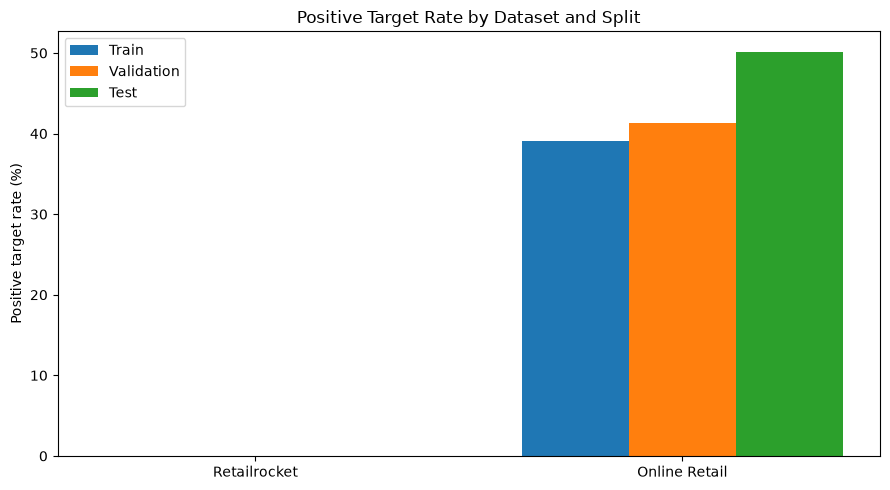

In [19]:

plot_rows = []

for _, row in rr_modeling_summary.iterrows():
    plot_rows.append({
        "dataset": "Retailrocket",
        "split": row["split"],
        "target_rate_pct": row["target_rate_pct"],
    })

for _, row in or_modeling_summary.iterrows():
    plot_rows.append({
        "dataset": "Online Retail",
        "split": row["split"],
        "target_rate_pct": row["target_rate_pct"],
    })

target_rate_plot = pd.DataFrame(plot_rows)

fig_target_rates, ax = plt.subplots(figsize=(9, 5))

datasets = ["Retailrocket", "Online Retail"]
splits = ["train", "validation", "test"]

x = np.arange(len(datasets))
width = 0.25

for i, split_name in enumerate(splits):
    values = []

    for dataset in datasets:
        row = target_rate_plot.loc[
            (target_rate_plot["dataset"] == dataset)
            & (target_rate_plot["split"] == split_name),
            "target_rate_pct",
        ]
        values.append(row.iloc[0] if len(row) else np.nan)

    ax.bar(
        x + (i - 1) * width,
        values,
        width,
        label=split_name.title(),
    )

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel("Positive target rate (%)")
ax.set_title("Positive Target Rate by Dataset and Split")
ax.legend()

fig_target_rates.tight_layout()
plt.show()


## 6. Save compact Notebook 07 results

In [20]:

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "07_feature_engineering_and_dataset_split"
)

TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RESULT_TABLES = {
    "split_boundaries": all_boundaries,
    "retailrocket_cutoff_summary": rr_cutoff_summary,
    "retailrocket_modeling_summary": rr_modeling_summary,
    "online_retail_admin_filter_summary": admin_filter_summary,
    "online_retail_cutoff_summary": or_cutoff_summary,
    "online_retail_modeling_summary": or_modeling_summary,
    "criteo_modeling_manifest": criteo_manifest,
    "target_rate_plot_data": target_rate_plot,
}

RESULT_FIGURES = {
    "target_rate_by_dataset_and_split": fig_target_rates,
}

for name, table in RESULT_TABLES.items():
    table.to_csv(TABLES_DIR / f"{name}.csv", index=False)

for name, fig in RESULT_FIGURES.items():
    fig.savefig(
        FIGURES_DIR / f"{name}.png",
        dpi=200,
        bbox_inches="tight",
    )

print("=" * 72)
print("NOTEBOOK 07 COMPLETE")
print("=" * 72)

print("\nRetailrocket split files:")
for split_name in ["train", "validation", "test"]:
    print(" -", RR_OUT / f"{split_name}.parquet")

print("\nOnline Retail split files:")
for split_name in ["train", "validation", "test"]:
    print(" -", OR_OUT / f"{split_name}.parquet")

print("\nResults:")
print(RESULTS_DIR)


NOTEBOOK 07 COMPLETE

Retailrocket split files:
 - /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/retailrocket/train.parquet
 - /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/retailrocket/validation.parquet
 - /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/retailrocket/test.parquet

Online Retail split files:
 - /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/online_retail/train.parquet
 - /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/online_retail/validation.parquet
 - /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling/online_retail/test.parquet

Results:
/Users/noopur/Desktop/resume_projects/ProductPulse/results/07_feature_engineering_and_dataset_split
